# Coastal Frontier — Geographic Analysis

**Where the southward spread actually happens in space.**

Notebook 02 established that H1 is supported with an extension pattern. This notebook
shows *where*. Five maps in order:

1. **Overview** — all 3,096 events 2020–2026 on the seven-country region
2. **Year facet** — small multiples showing year-by-year evolution
3. **Frontier in space** — the M1 5th-percentile latitude line tracked across years
4. **Littoral close-up** — Togo, Benin, Côte d'Ivoire, Ghana — where the new activity sits
5. **Hotspots** — kernel density of recent events to identify the corridors

Each map has three layers: base, data, annotation. Annotations are non-negotiable —
country labels, legends, scale, and titles let a reader interpret the map standalone.

In [1]:
# --- Imports and setup ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.coastal_frontier.config import DATA_INTERIM

sns.set_style("white")
plt.rcParams["figure.dpi"] = 100

# West Africa bounding box for our region
LON_MIN, LON_MAX = -9.0, 4.5
LAT_MIN, LAT_MAX = 4.0, 16.5

# Country centroids for labeling (rough)
COUNTRY_CENTROIDS = {
    "Mali":         (-3.5, 14.5),
    "Burkina Faso": (-1.5, 12.7),
    "Niger":        ( 2.0, 14.0),
    "Togo":         ( 1.0,  8.5),
    "Benin":        ( 2.3,  9.0),
    "Ghana":        (-1.0,  7.5),
    "Ivory Coast":  (-5.5,  7.5),
}

SAHEL_CORE = {"Mali", "Burkina Faso", "Niger"}
LITTORAL = {"Togo", "Benin", "Ivory Coast", "Ghana"}

print("Setup complete; bounding box:", LON_MIN, LAT_MIN, "to", LON_MAX, LAT_MAX)

Setup complete; bounding box: -9.0 4.0 to 4.5 16.5


In [2]:
# --- Load events as a GeoDataFrame ---
df = pd.read_parquet(DATA_INTERIM / "ucdp_events_filtered.parquet")
df["date_start"] = pd.to_datetime(df["date_start"])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",  # WGS84 — what UCDP lat/lon are in
)

print(f"Built GeoDataFrame: {len(gdf):,} events")
print(f"CRS: {gdf.crs}")
print(f"Lon range: {gdf.geometry.x.min():.2f} to {gdf.geometry.x.max():.2f}")
print(f"Lat range: {gdf.geometry.y.min():.2f} to {gdf.geometry.y.max():.2f}")

Built GeoDataFrame: 3,096 events
CRS: EPSG:4326
Lon range: -11.79 to 13.50
Lat range: 5.69 to 21.07


## Map 1 — Overview

All 3,096 events on the region. Points colored by year so the temporal dimension is
visible at a glance — earlier years darker, recent years lighter. The leading edge
of the cluster is where the southern frontier sits.

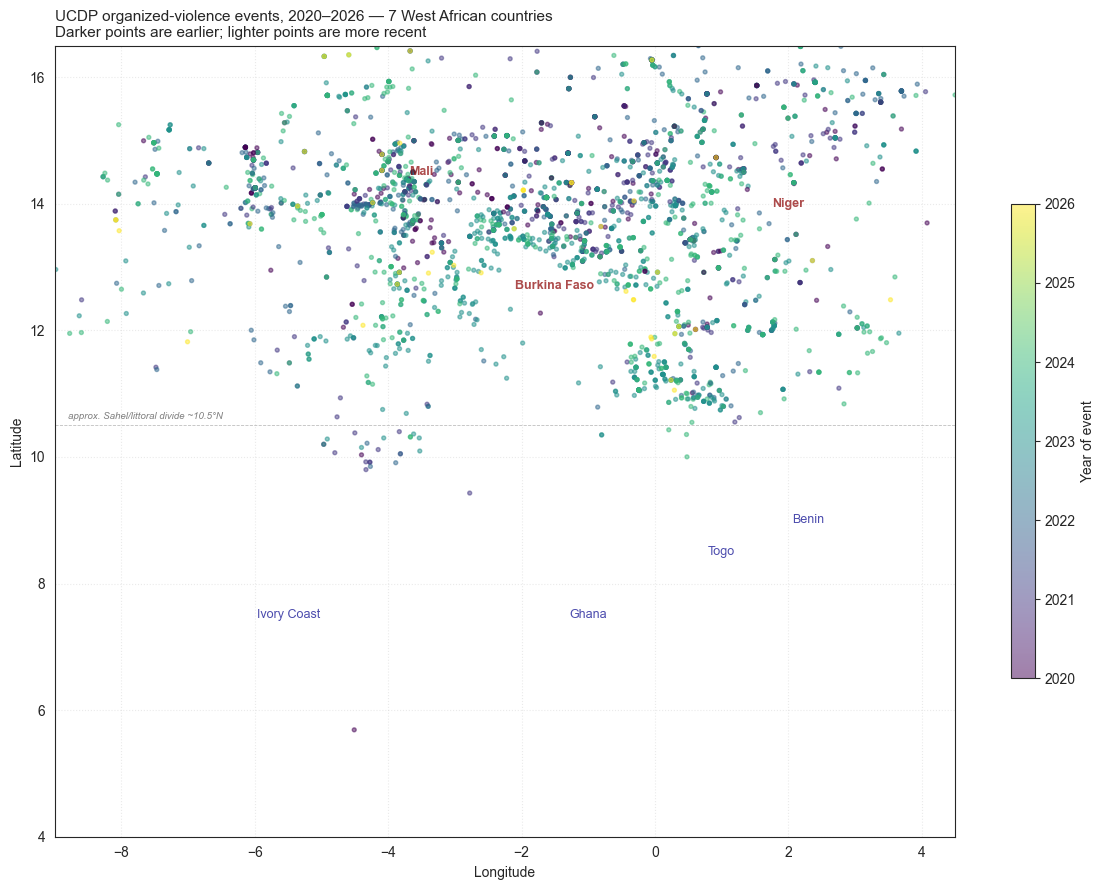

In [3]:
def annotate_basemap(ax):
    """Add country labels and bounding-box framing — the annotation layer."""
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle=":", alpha=0.4)
    for country, (lon, lat) in COUNTRY_CENTROIDS.items():
        weight = "bold" if country in SAHEL_CORE else "normal"
        color = "darkred" if country in SAHEL_CORE else "darkblue"
        ax.text(lon, lat, country, ha="center", va="center",
                fontsize=9, fontweight=weight, color=color, alpha=0.7)
    # Latitude lines highlighting Sahel/littoral approximate divide (~10°N)
    ax.axhline(10.5, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.text(LON_MIN + 0.2, 10.6, "approx. Sahel/littoral divide ~10.5°N",
            fontsize=7, style="italic", color="gray")

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=gdf["year"], cmap="viridis", s=8, alpha=0.5,
)
annotate_basemap(ax)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label("Year of event")
ax.set_title("UCDP organized-violence events, 2020–2026 — 7 West African countries\nDarker points are earlier; lighter points are more recent",
             fontsize=11, loc="left")
plt.tight_layout()
plt.show()

## Map 2 — Year-by-year evolution

Small multiples. Each panel shows one year's events, all on the same bounding box.
Looking across panels reveals the southward extension visually — events appearing in
the bottom of the frame where they weren't before.

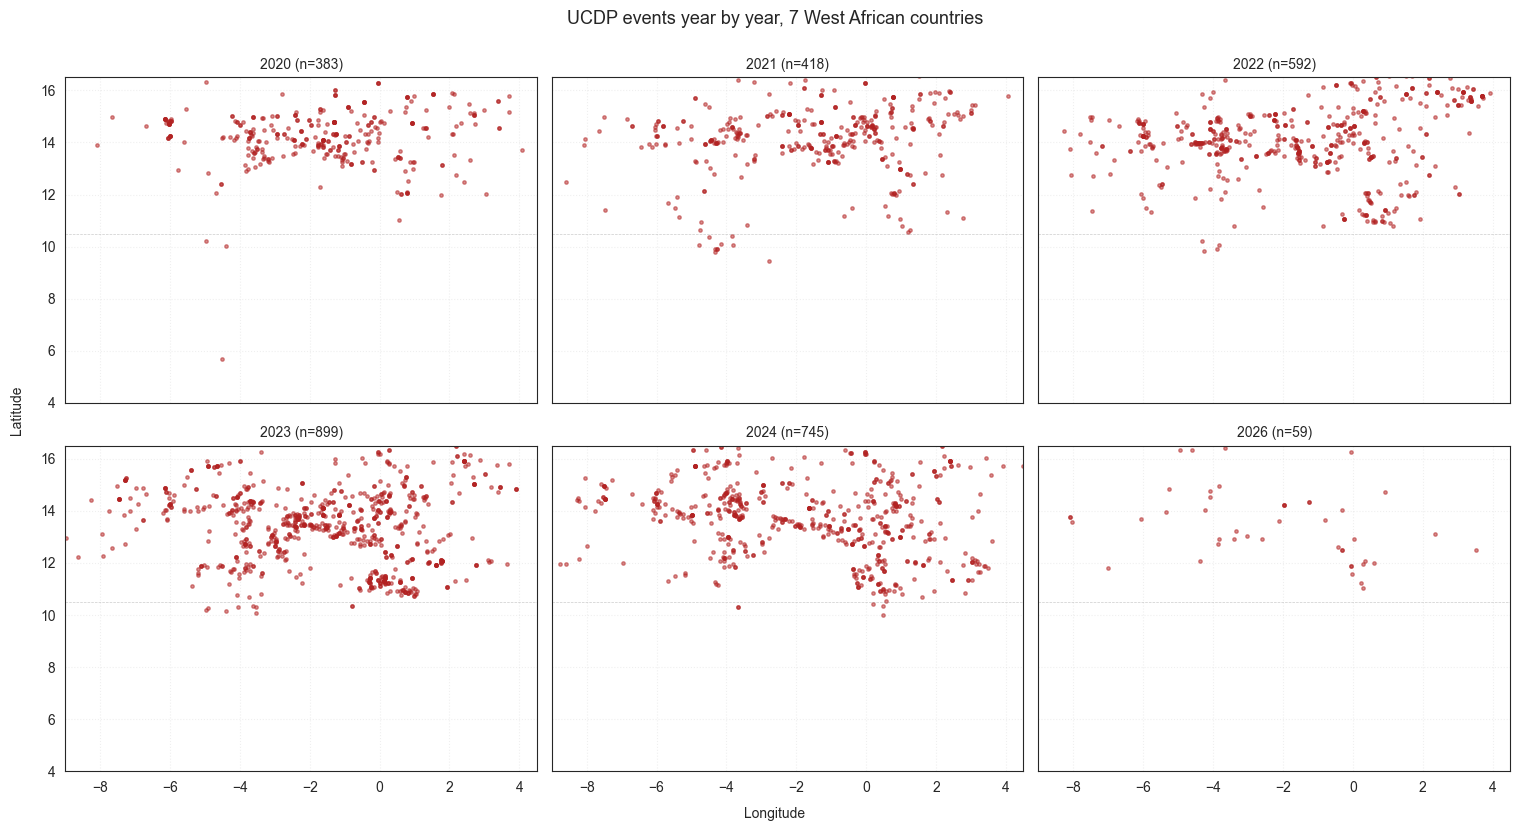

In [4]:
years_present = sorted(gdf["year"].unique())
n_years = len(years_present)
ncols = 3
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, year in enumerate(years_present):
    ax = axes[i]
    yr_gdf = gdf[gdf["year"] == year]
    ax.scatter(yr_gdf.geometry.x, yr_gdf.geometry.y,
               c="firebrick", s=6, alpha=0.5)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.grid(True, linestyle=":", alpha=0.3)
    ax.axhline(10.5, color="gray", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_title(f"{year} (n={len(yr_gdf):,})", fontsize=10)

# Hide any unused subplots
for j in range(n_years, len(axes)):
    axes[j].axis("off")

fig.suptitle("UCDP events year by year, 7 West African countries",
             fontsize=13, y=1.00)
fig.text(0.5, -0.01, "Longitude", ha="center")
fig.text(-0.01, 0.5, "Latitude", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

## Map 3 — The frontier in space

Recall M1: the 5th-percentile latitude per quarter, which captures the leading edge.
Here we draw that frontier per year as a horizontal line. If the lines step
progressively downward (south), H1 is visually confirmed.

   year  frontier_lat_p05
0  2020         12.764167
1  2021         11.322529
2  2022         11.351279
3  2023         11.058056
4  2024         11.318009
5  2026         11.796217


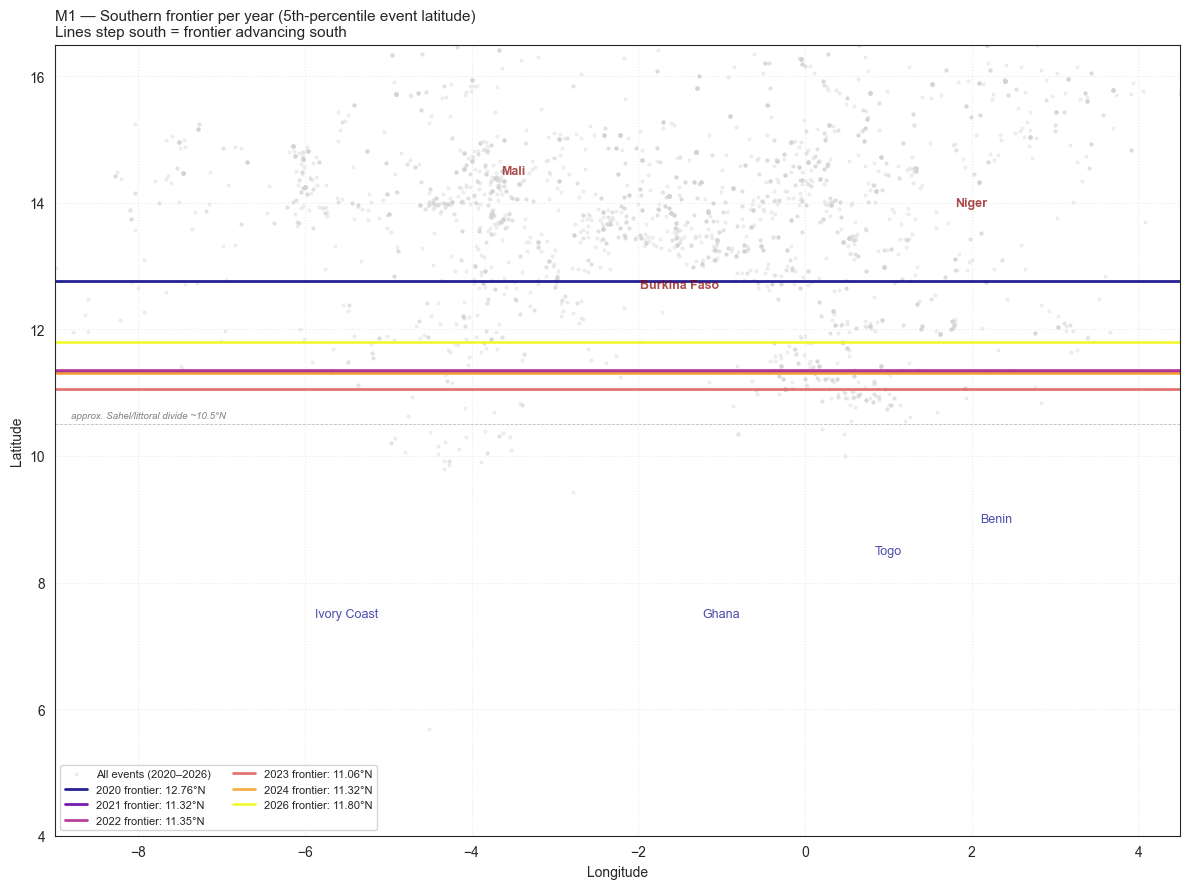

In [5]:
# Compute 5th-percentile latitude per year
frontier_by_year = gdf.groupby("year")["latitude"].quantile(0.05).reset_index()
frontier_by_year.columns = ["year", "frontier_lat_p05"]
print(frontier_by_year)

fig, ax = plt.subplots(figsize=(12, 9))

# Light scatter of all events as context
ax.scatter(gdf.geometry.x, gdf.geometry.y,
           color="lightgray", s=4, alpha=0.3, label="All events (2020–2026)")

# Color the frontier lines by year
cmap = plt.cm.plasma
n = len(frontier_by_year)
for i, row in frontier_by_year.iterrows():
    color = cmap(i / max(n - 1, 1))
    ax.axhline(row["frontier_lat_p05"], color=color, linewidth=2, alpha=0.9,
               label=f"{int(row['year'])} frontier: {row['frontier_lat_p05']:.2f}°N")

annotate_basemap(ax)
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.set_title("M1 — Southern frontier per year (5th-percentile event latitude)\nLines step south = frontier advancing south",
             fontsize=11, loc="left")
plt.tight_layout()
plt.show()

## Map 4 — Littoral close-up

Zoom into the four southern countries. This is where the new activity is appearing.
Events colored by year again so the *appearance* of activity over time is visible.

Littoral events: 116
country
Benin          58
Togo           40
Ghana          17
Ivory Coast     1
Name: count, dtype: int64


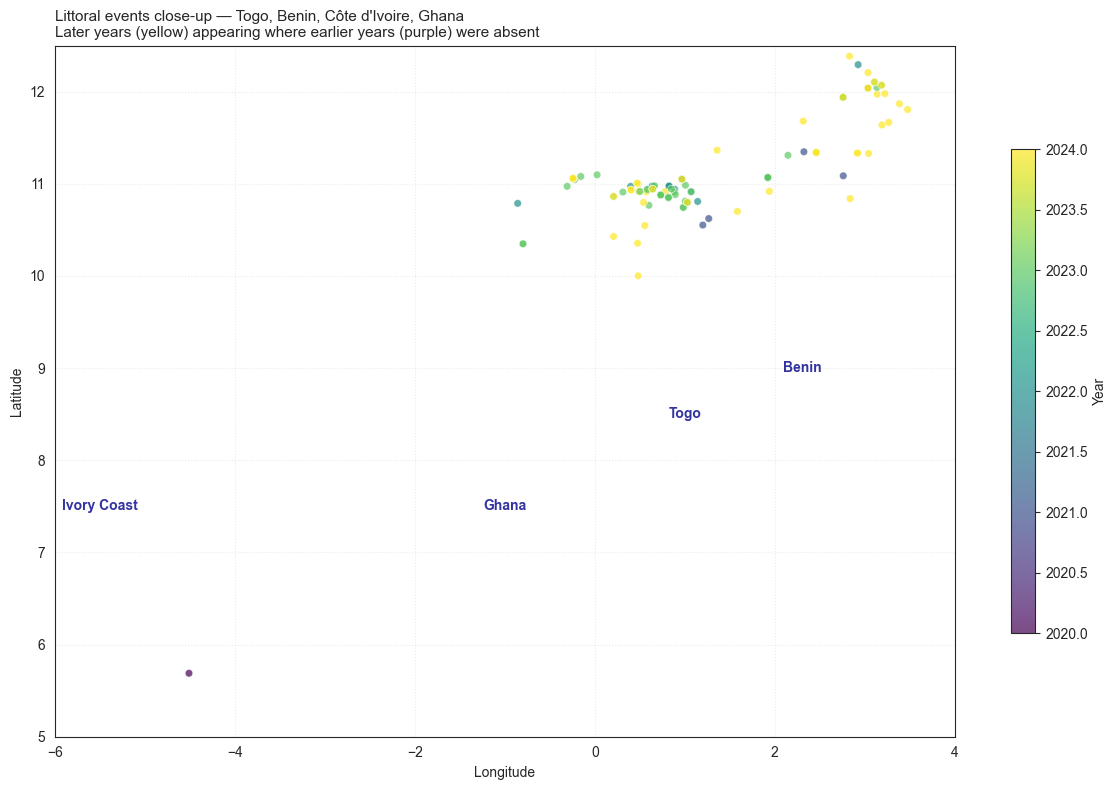

In [6]:
littoral_gdf = gdf[gdf["country"].isin(LITTORAL)]
print(f"Littoral events: {len(littoral_gdf):,}")
print(littoral_gdf["country"].value_counts())

# Tighter bounding box for the littoral
L_LON_MIN, L_LON_MAX = -6.0, 4.0
L_LAT_MIN, L_LAT_MAX = 5.0, 12.5

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    littoral_gdf.geometry.x, littoral_gdf.geometry.y,
    c=littoral_gdf["year"], cmap="viridis", s=30, alpha=0.7, edgecolors="white", linewidths=0.5,
)
ax.set_xlim(L_LON_MIN, L_LON_MAX)
ax.set_ylim(L_LAT_MIN, L_LAT_MAX)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", alpha=0.4)

for country in LITTORAL:
    lon, lat = COUNTRY_CENTROIDS[country]
    ax.text(lon, lat, country, ha="center", va="center",
            fontsize=10, fontweight="bold", color="darkblue", alpha=0.8)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Year")
ax.set_title("Littoral events close-up — Togo, Benin, Côte d'Ivoire, Ghana\nLater years (yellow) appearing where earlier years (purple) were absent",
             fontsize=11, loc="left")
plt.tight_layout()
plt.show()

## Map 5 — Hotspots (kernel density)

Where the highest density of events sits. We use a 2D histogram (hexagonal binning)
because it's robust and interpretable: each cell shows the count of events that fell
inside its area. The brightest cells are the corridors of greatest violence.

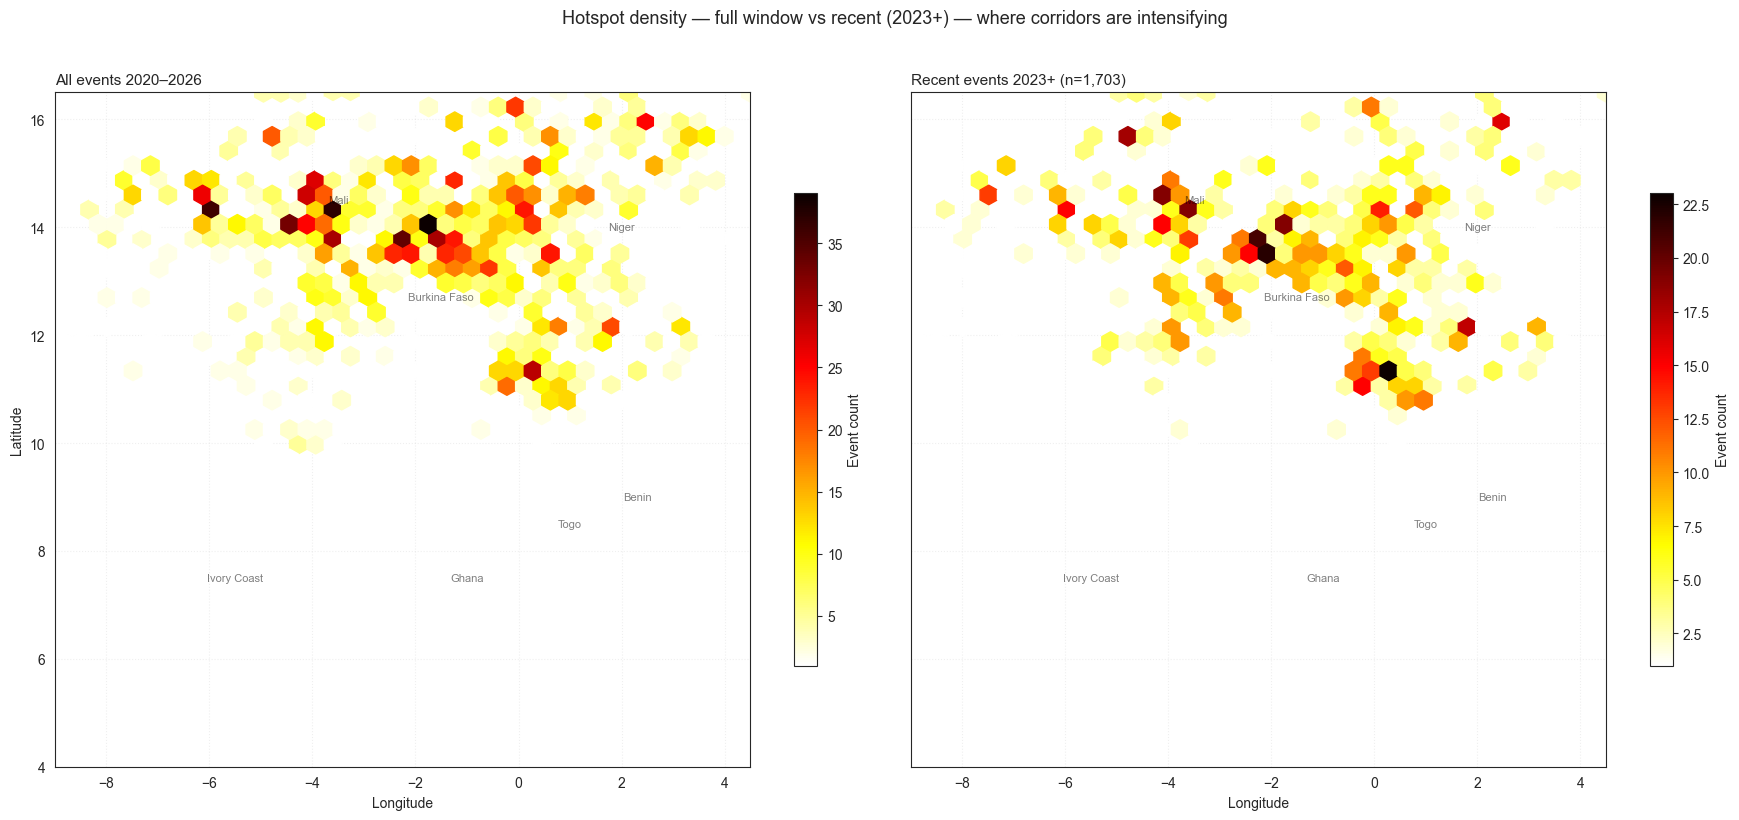

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# All-period hotspots
hb = axes[0].hexbin(gdf.geometry.x, gdf.geometry.y,
                    gridsize=40, cmap="hot_r", mincnt=1,
                    extent=(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX))
axes[0].set_xlim(LON_MIN, LON_MAX)
axes[0].set_ylim(LAT_MIN, LAT_MAX)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("All events 2020–2026", fontsize=11, loc="left")
axes[0].grid(True, linestyle=":", alpha=0.3)
plt.colorbar(hb, ax=axes[0], shrink=0.7, label="Event count")
for country, (lon, lat) in COUNTRY_CENTROIDS.items():
    axes[0].text(lon, lat, country, ha="center", va="center",
                 fontsize=8, color="black", alpha=0.5)

# Recent (2023+) hotspots
recent_gdf = gdf[gdf["year"] >= 2023]
hb2 = axes[1].hexbin(recent_gdf.geometry.x, recent_gdf.geometry.y,
                     gridsize=40, cmap="hot_r", mincnt=1,
                     extent=(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX))
axes[1].set_xlim(LON_MIN, LON_MAX)
axes[1].set_ylim(LAT_MIN, LAT_MAX)
axes[1].set_xlabel("Longitude")
axes[1].set_title(f"Recent events 2023+ (n={len(recent_gdf):,})", fontsize=11, loc="left")
axes[1].grid(True, linestyle=":", alpha=0.3)
plt.colorbar(hb2, ax=axes[1], shrink=0.7, label="Event count")
for country, (lon, lat) in COUNTRY_CENTROIDS.items():
    axes[1].text(lon, lat, country, ha="center", va="center",
                 fontsize=8, color="black", alpha=0.5)

fig.suptitle("Hotspot density — full window vs recent (2023+) — where corridors are intensifying",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Findings — what the maps show

"The southern frontier dropped sharply in 2021 — coinciding with the Mali coup wave — and reached its most-southern extent in 2023 alongside Burkina Faso's coup-and-Wagner period. Since 2024, the frontier has partially retreated, though preliminary 2026 data is sparse."

**Visible patterns:**
The frontier did not advance linearly. The largest single-year drop was 2020→2021 (1.44° south); 2023 reached the most-southern frontier of the analysis window; 2024 and 2026 show partial retreat. This stepwise pattern is hidden by the linear trend slope reported in notebook 02 but is operationally important — the brief's narrative should emphasize episodic acceleration rather than steady creep.

The Sahel-core hotspots (north Mali, Mopti, central Burkina) remained active across the entire window. New southern-edge hotspots emerged in 2023+ without displacing the old ones — the visual confirmation of extension, not shift.

**Districts worth flagging for security cooperation focus** 
The Burkina/Togo/Benin tri-border zone (centered near ~1°E, 11°N) is the dominant spillover corridor — concentrating roughly two-thirds of all littoral events.
Northern Benin shows the strongest year-over-year growth (1 → 58 events). Northern Togo follows (0 → 40). These two adjacencies to Burkina Faso are the operational priority for security cooperation.
Ghana's spillover is real but smaller and concentrated in the Upper East / Upper West regions adjacent to Burkina.
Côte d'Ivoire has effectively zero UCDP-recorded events (1 in six years). Either no measurable spillover yet, or the events are below UCDP's threshold.

**What the maps cannot tell us (data limitations made visible):**
The 2024–2026 frontier retreat may be a reporting artifact — post-coup media restrictions in Burkina Faso and Niger likely under-state recent Sahel-core events, which could artificially shift the regional frontier north. The same restrictions do not affect littoral states. We name this as a methodology caveat and flag a comparison with ACLED (if/when access is granted) as the natural follow-up.